In [1]:
# Hyperparameters and Optimization
# Wine Classification with PyTorch

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# --------------------------------------------------
# 1. Reproducibility
# --------------------------------------------------

np.random.seed(0)
torch.manual_seed(0)


# --------------------------------------------------
# 2. Load Wine dataset
# --------------------------------------------------

wine = load_wine()

X = wine.data
y = wine.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", wine.target_names)


# --------------------------------------------------
# 3. Train/test split and standardization
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


# --------------------------------------------------
# 4. Create mini-batches
# --------------------------------------------------

def create_batches(X, y, batch_size):
    indices = torch.randperm(X.shape[0])

    for start in range(0, X.shape[0], batch_size):
        batch_indices = indices[start:start + batch_size]
        yield X[batch_indices], y[batch_indices]


# --------------------------------------------------
# 5. Build ANN model
# --------------------------------------------------

def build_model():
    model = nn.Sequential(
        nn.Linear(13, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 3)
    )
    return model


# --------------------------------------------------
# 6. Train and evaluate model
# --------------------------------------------------

def train_model(
    optimizer_name="Adam",
    learning_rate=0.001,
    batch_size=16,
    num_epochs=200
):

    model = build_model()
    loss_function = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "RMSProp":
        optimizer = torch.optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )

    else:
        raise ValueError("Unsupported optimizer")

    train_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):

        model.train()
        epoch_loss = 0

        for X_batch, y_batch in create_batches(
            X_train,
            y_train,
            batch_size
        ):

            outputs = model(X_batch)
            loss = loss_function(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        average_loss = epoch_loss / len(
            list(create_batches(X_train, y_train, batch_size))
        )

        model.eval()

        with torch.no_grad():
            test_outputs = model(X_test)
            test_predictions = torch.argmax(test_outputs, dim=1)

            test_accuracy = (
                test_predictions == y_test
            ).float().mean() * 100

        train_losses.append(average_loss)
        test_accuracies.append(test_accuracy.item())

    return {
        "optimizer": optimizer_name,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "epochs": num_epochs,
        "final_loss": train_losses[-1],
        "final_accuracy": test_accuracies[-1],
        "train_losses": train_losses,
        "test_accuracies": test_accuracies
    }



Feature shape: (178, 13)
Target shape: (178,)
Classes: ['class_0' 'class_1' 'class_2']


Learning Rate: 0.0001 | Final Accuracy: 97.22%
Learning Rate: 0.001 | Final Accuracy: 94.44%
Learning Rate: 0.01 | Final Accuracy: 97.22%
Learning Rate: 0.1 | Final Accuracy: 100.00%


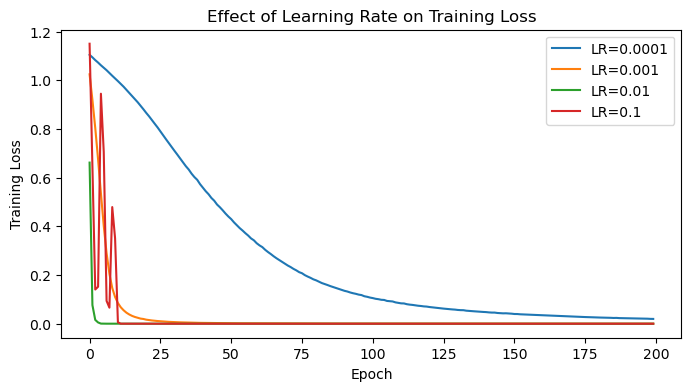

In [2]:

# --------------------------------------------------
# 7. Experiment 1: Learning rate comparison
# --------------------------------------------------

learning_rates = [0.0001, 0.001, 0.01, 0.1]

lr_results = []

for lr in learning_rates:

    result = train_model(
        optimizer_name="Adam",
        learning_rate=lr,
        batch_size=16,
        num_epochs=200
    )

    lr_results.append(result)

    print(
        f"Learning Rate: {lr} | "
        f"Final Accuracy: {result['final_accuracy']:.2f}%"
    )


plt.figure(figsize=(8, 4))

for result in lr_results:
    plt.plot(
        result["train_losses"],
        label=f"LR={result['learning_rate']}"
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Effect of Learning Rate on Training Loss")
plt.legend()
plt.show()



Batch Size: 4 | Final Accuracy: 94.44%
Batch Size: 16 | Final Accuracy: 97.22%
Batch Size: 32 | Final Accuracy: 97.22%
Batch Size: 64 | Final Accuracy: 97.22%


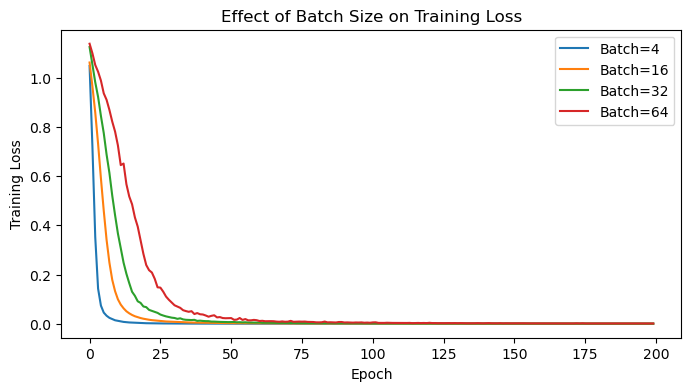

In [3]:

# --------------------------------------------------
# 8. Experiment 2: Batch size comparison
# --------------------------------------------------

batch_sizes = [4, 16, 32, 64]

batch_results = []

for batch_size in batch_sizes:

    result = train_model(
        optimizer_name="Adam",
        learning_rate=0.001,
        batch_size=batch_size,
        num_epochs=200
    )

    batch_results.append(result)

    print(
        f"Batch Size: {batch_size} | "
        f"Final Accuracy: {result['final_accuracy']:.2f}%"
    )


plt.figure(figsize=(8, 4))

for result in batch_results:
    plt.plot(
        result["train_losses"],
        label=f"Batch={result['batch_size']}"
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Effect of Batch Size on Training Loss")
plt.legend()
plt.show()



Optimizer: SGD | Final Accuracy: 91.67%
Optimizer: Adam | Final Accuracy: 97.22%
Optimizer: RMSProp | Final Accuracy: 97.22%


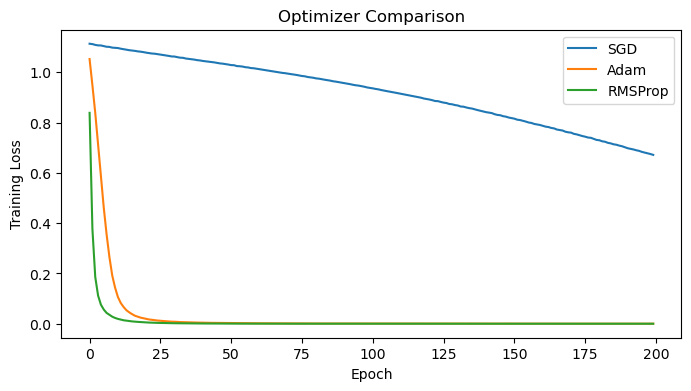

In [4]:

# --------------------------------------------------
# 9. Experiment 3: Optimizer comparison
# --------------------------------------------------

optimizers = ["SGD", "Adam", "RMSProp"]

optimizer_results = []

for optimizer_name in optimizers:

    result = train_model(
        optimizer_name=optimizer_name,
        learning_rate=0.001,
        batch_size=16,
        num_epochs=200
    )

    optimizer_results.append(result)

    print(
        f"Optimizer: {optimizer_name} | "
        f"Final Accuracy: {result['final_accuracy']:.2f}%"
    )


plt.figure(figsize=(8, 4))

for result in optimizer_results:
    plt.plot(
        result["train_losses"],
        label=result["optimizer"]
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()



In [5]:

# --------------------------------------------------
# 10. Experiment 4: Epoch comparison
# --------------------------------------------------

epoch_options = [50, 100, 200, 400]

epoch_results = []

for epochs in epoch_options:

    result = train_model(
        optimizer_name="Adam",
        learning_rate=0.001,
        batch_size=16,
        num_epochs=epochs
    )

    epoch_results.append(result)

    print(
        f"Epochs: {epochs} | "
        f"Final Accuracy: {result['final_accuracy']:.2f}%"
    )


Epochs: 50 | Final Accuracy: 97.22%
Epochs: 100 | Final Accuracy: 94.44%
Epochs: 200 | Final Accuracy: 94.44%
Epochs: 400 | Final Accuracy: 97.22%


In [6]:


# --------------------------------------------------
# 11. Summary table
# --------------------------------------------------

summary_rows = []

for result in lr_results:
    summary_rows.append({
        "Experiment": "Learning Rate",
        "Setting": result["learning_rate"],
        "Final Loss": result["final_loss"],
        "Final Accuracy": result["final_accuracy"]
    })

for result in batch_results:
    summary_rows.append({
        "Experiment": "Batch Size",
        "Setting": result["batch_size"],
        "Final Loss": result["final_loss"],
        "Final Accuracy": result["final_accuracy"]
    })

for result in optimizer_results:
    summary_rows.append({
        "Experiment": "Optimizer",
        "Setting": result["optimizer"],
        "Final Loss": result["final_loss"],
        "Final Accuracy": result["final_accuracy"]
    })

for result in epoch_results:
    summary_rows.append({
        "Experiment": "Epochs",
        "Setting": result["epochs"],
        "Final Loss": result["final_loss"],
        "Final Accuracy": result["final_accuracy"]
    })

summary_df = pd.DataFrame(summary_rows)

summary_df

,Experiment,Setting,Final Loss,Final Accuracy
0,Learning Rate,0.0001,1.974205e-02,97.222221
1,Learning Rate,0.001,9.286467e-05,94.444443
2,Learning Rate,0.01,2.144440e-06,97.222221
3,Learning Rate,0.1,1.250036e-07,100.000000
4,Batch Size,4,3.211979e-06,94.444443
5,Batch Size,16,1.248178e-04,97.222221
6,Batch Size,32,3.259007e-04,97.222221
7,Batch Size,64,8.503106e-04,97.222221
8,Optimizer,SGD,6.716455e-01,91.666672
9,Optimizer,Adam,1.283417e-04,97.222221
